<a href="https://colab.research.google.com/github/natrask/ENM5320-2026/blob/main/old_material/NeuralODE_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural ODE Tutorial

This notebook demonstrates how to train a **Neural ODE** — a neural network that parameterizes the right-hand side of an ordinary differential equation:
$$\frac{d\mathbf{x}}{dt} = f_\theta(\mathbf{x}, t)$$

Instead of hand-specifying $f$, we let a neural network learn it from trajectory data. The key idea from [Chen et al. (2018)](https://arxiv.org/abs/1806.07366) is that we can backpropagate through the ODE solver, making the whole pipeline end-to-end differentiable.

We use [`torchdiffeq`](https://github.com/rtqichen/torchdiffeq), the reference implementation by the original authors.

**What you'll learn:**
1. How to generate trajectory data from a known ODE
2. How to define a Neural ODE model using `torchdiffeq`
3. How to train it to recover unknown dynamics from observations
4. How to evaluate generalization (forecasting beyond training data)

## 1. Setup and imports

Install `torchdiffeq` (provides `odeint` for differentiable ODE solving) and import dependencies.

In [ ]:
!pip install torchdiffeq

import torch
import torch.nn as nn
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Generate ground-truth data

We generate trajectory data from a **2D linear ODE** with complex eigenvalues, which produces spiral dynamics:
$$\frac{d\mathbf{x}}{dt} = A\,\mathbf{x}, \qquad A = \begin{pmatrix} -0.1 & 1.0 \\ -1.0 & -0.1 \end{pmatrix}$$

This is a damped rotation — simple enough to visualize, but nontrivial enough that the Neural ODE must learn both the rotational and dissipative components.

We solve the true ODE to get clean trajectories, then add noise to simulate real observations.

In [10]:
# True dynamics: dx/dt = A @ x (damped spiral)
A_true = torch.tensor([[-0.1, 1.0],
                        [-1.0, -0.1]], device=device)

class TrueODE(nn.Module):
    def forward(self, t, x):
        return x @ A_true.T

# Initial condition and time points
x0 = torch.tensor([[2.0, 0.0]], device=device)  # shape: [1, 2]

# Training data: observe the trajectory from t=0 to t=10
t_train = torch.linspace(0, 10, 50, device=device)

# Generate clean trajectory
with torch.no_grad():
    x_true = odeint(TrueODE(), x0, t_train)  # shape: [50, 1, 2]

# Add observation noise
noise_std = 0.05
x_obs = x_true + noise_std * torch.randn_like(x_true)

print(f"Trajectory shape: {x_true.shape}  (time_steps, batch, state_dim)")

Trajectory shape: torch.Size([50, 1, 2])  (time_steps, batch, state_dim)


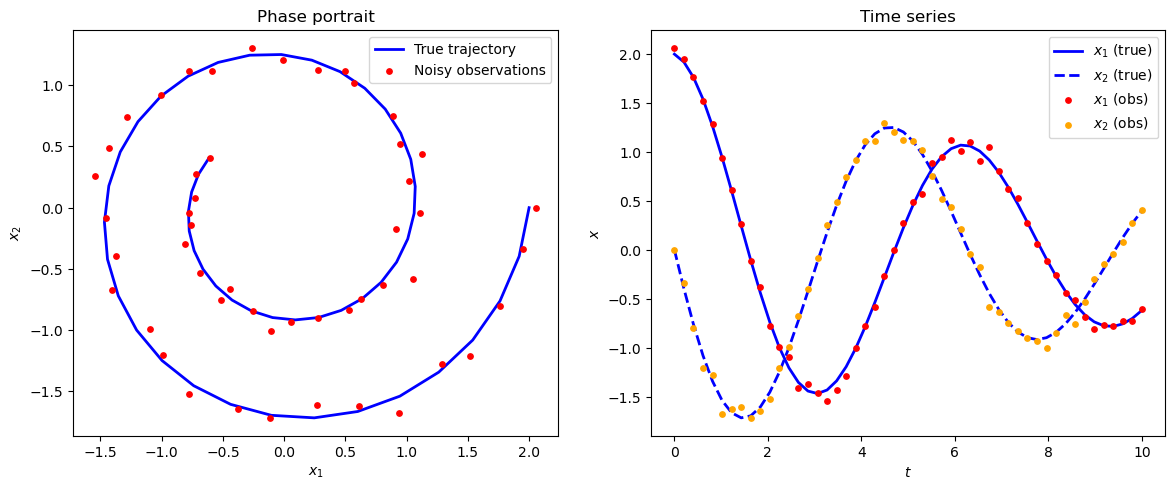

In [11]:
# Visualize the ground truth and noisy observations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Phase portrait (x1 vs x2)
xt = x_true[:, 0, :].cpu()
xo = x_obs[:, 0, :].cpu()
ax1.plot(xt[:, 0], xt[:, 1], 'b-', label='True trajectory', linewidth=2)
ax1.scatter(xo[:, 0], xo[:, 1], c='r', s=15, zorder=5, label='Noisy observations')
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$')
ax1.set_title('Phase portrait'); ax1.legend(); ax1.set_aspect('equal')

# Time series
tt = t_train.cpu()
ax2.plot(tt, xt[:, 0], 'b-', label='$x_1$ (true)', linewidth=2)
ax2.plot(tt, xt[:, 1], 'b--', label='$x_2$ (true)', linewidth=2)
ax2.scatter(tt, xo[:, 0], c='r', s=15, zorder=5, label='$x_1$ (obs)')
ax2.scatter(tt, xo[:, 1], c='orange', s=15, zorder=5, label='$x_2$ (obs)')
ax2.set_xlabel('$t$'); ax2.set_ylabel('$x$')
ax2.set_title('Time series'); ax2.legend()

plt.tight_layout()
plt.show()

## 3. Define the Neural ODE model

The model has two parts:
1. **`ODEFunc`** — a small MLP that represents $f_\theta(\mathbf{x}, t)$. Given the current state $\mathbf{x}$, it outputs $d\mathbf{x}/dt$.
2. **`NeuralODE`** — wraps `ODEFunc` and calls `torchdiffeq.odeint` to integrate from the initial condition over the requested time points.

Note: the `t` argument is passed to `ODEFunc.forward` by the ODE solver but we ignore it here (autonomous system). For non-autonomous systems, you would concatenate $t$ to the input.

In [ ]:
class ODEFunc(nn.Module):
    """Neural network approximation of dx/dt = f(x)."""
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, t, x):
        return self.net(x)


class NeuralODE(nn.Module):
    """Integrate ODEFunc over given time points."""
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x0, t):
        # odeint returns shape [len(t), *x0.shape]
        return odeint(self.func, x0, t)


# Instantiate
func = ODEFunc(state_dim=2, hidden_dim=64).to(device)
model = NeuralODE(func).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params}")

Model parameters: 4482


## 4. Training

We minimize the MSE between the predicted trajectory and the noisy observations:
$$\mathcal{L}(\theta) = \frac{1}{T}\sum_{i=1}^{T} \|\hat{\mathbf{x}}(t_i) - \mathbf{x}^{\mathrm{obs}}(t_i)\|^2, \qquad \hat{\mathbf{x}}(t_i) = \mathbf{x}_0 + \int_0^{t_i} f_\theta(\mathbf{x}, t)\,dt$$

The gradient $\partial\mathcal{L}/\partial\theta$ is computed automatically — `torchdiffeq.odeint` supports backpropagation through the solver.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 500

loss_history = []
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Forward: integrate the Neural ODE from x0 over t_train
    x_pred = model(x0, t_train)  # shape: [50, 1, 2]

    # Loss: compare predicted trajectory to noisy observations
    loss = nn.functional.mse_loss(x_pred, x_obs)

    # Backward: gradients flow through the ODE solver
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:4d}/{num_epochs}  Loss: {loss.item():.6f}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

Epoch   10/500  Loss: 0.987011
Epoch   20/500  Loss: 0.837416


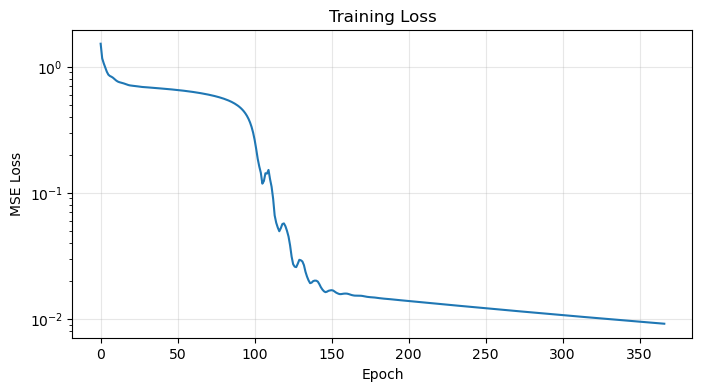

In [6]:
plt.figure(figsize=(8, 4))
plt.semilogy(loss_history)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Results

### Training fit
Compare the learned trajectory against observations over the training interval $[0, 10]$.

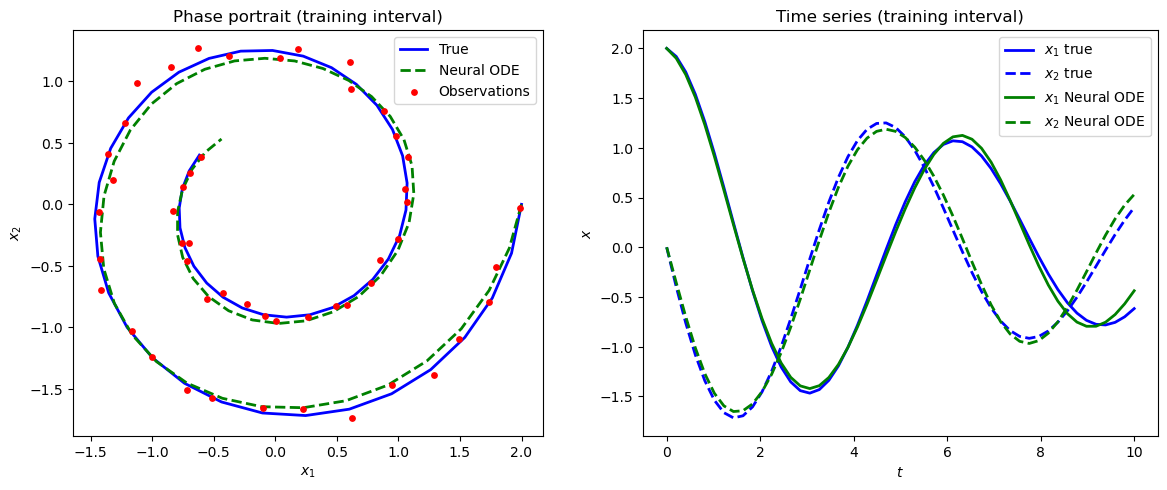

In [7]:
with torch.no_grad():
    x_pred = model(x0, t_train)

xp = x_pred[:, 0, :].cpu()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(xt[:, 0], xt[:, 1], 'b-', label='True', linewidth=2)
ax1.plot(xp[:, 0], xp[:, 1], 'g--', label='Neural ODE', linewidth=2)
ax1.scatter(xo[:, 0], xo[:, 1], c='r', s=15, zorder=5, label='Observations')
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$')
ax1.set_title('Phase portrait (training interval)')
ax1.legend(); ax1.set_aspect('equal')

ax2.plot(tt, xt[:, 0], 'b-', label='$x_1$ true', linewidth=2)
ax2.plot(tt, xt[:, 1], 'b--', label='$x_2$ true', linewidth=2)
ax2.plot(tt, xp[:, 0], 'g-', label='$x_1$ Neural ODE', linewidth=2)
ax2.plot(tt, xp[:, 1], 'g--', label='$x_2$ Neural ODE', linewidth=2)
ax2.set_xlabel('$t$'); ax2.set_ylabel('$x$')
ax2.set_title('Time series (training interval)')
ax2.legend()

plt.tight_layout()
plt.show()

### Extrapolation
Integrate the learned dynamics *beyond* the training window to $t = 20$. Good extrapolation means the model has learned the actual structure of the dynamics, not just interpolated the data.

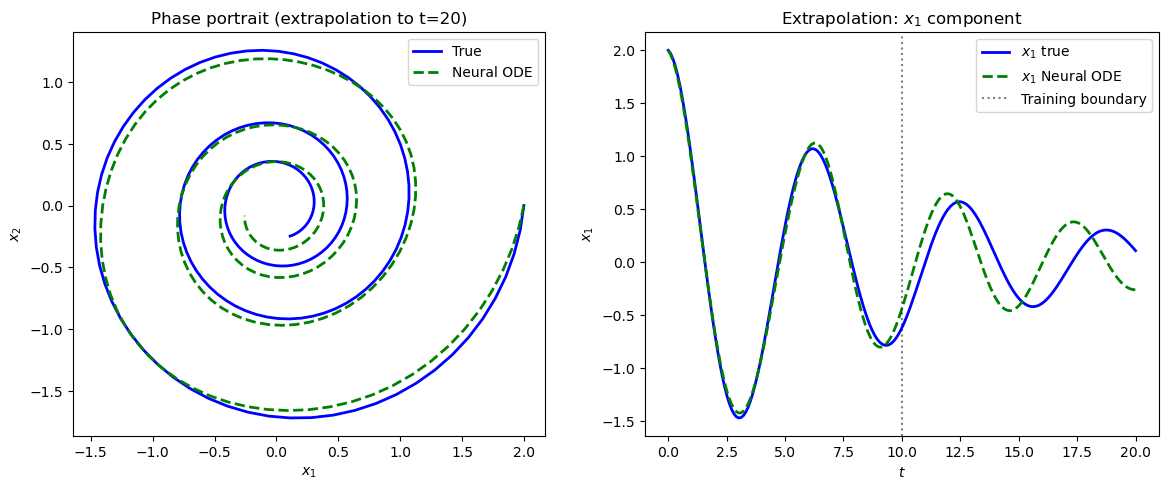

In [8]:
# Extrapolate: integrate from t=0 to t=20 (training only covered t=0 to t=10)
t_extrap = torch.linspace(0, 20, 200, device=device)

with torch.no_grad():
    x_true_ext = odeint(TrueODE(), x0, t_extrap)
    x_pred_ext = model(x0, t_extrap)

xte = x_true_ext[:, 0, :].cpu()
xpe = x_pred_ext[:, 0, :].cpu()
te = t_extrap.cpu()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(xte[:, 0], xte[:, 1], 'b-', label='True', linewidth=2)
ax1.plot(xpe[:, 0], xpe[:, 1], 'g--', label='Neural ODE', linewidth=2)
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$')
ax1.set_title('Phase portrait (extrapolation to t=20)')
ax1.legend(); ax1.set_aspect('equal')

ax2.plot(te, xte[:, 0], 'b-', label='$x_1$ true', linewidth=2)
ax2.plot(te, xpe[:, 0], 'g--', label='$x_1$ Neural ODE', linewidth=2)
ax2.axvline(x=10, color='k', linestyle=':', alpha=0.5, label='Training boundary')
ax2.set_xlabel('$t$'); ax2.set_ylabel('$x_1$')
ax2.set_title('Extrapolation: $x_1$ component')
ax2.legend()

plt.tight_layout()
plt.show()

### Learned vector field
Plot the vector field $f_\theta(\mathbf{x})$ learned by the network and compare it to the true field $A\mathbf{x}$.

In [ ]:
# Evaluate the learned vector field on a grid
grid = torch.linspace(-2.5, 2.5, 20)
X1, X2 = torch.meshgrid(grid, grid, indexing='ij')
grid_pts = torch.stack([X1.flatten(), X2.flatten()], dim=-1).to(device)  # [400, 2]

with torch.no_grad():
    # Learned field
    f_learned = func(0, grid_pts).cpu()
    # True field
    f_true = (grid_pts @ A_true.T).cpu()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
X1n, X2n = X1.numpy(), X2.numpy()

ax1.quiver(X1n, X2n, f_true[:, 0].reshape(20, 20).numpy(), f_true[:, 1].reshape(20, 20).numpy(), alpha=0.7)
ax1.set_title('True vector field $A\mathbf{x}$')
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.set_aspect('equal')

ax2.quiver(X1n, X2n, f_learned[:, 0].reshape(20, 20).numpy(), f_learned[:, 1].reshape(20, 20).numpy(), alpha=0.7)
ax2.set_title('Learned vector field $f_\\theta(\mathbf{x})$')
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$'); ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### Generalization to unseen initial conditions

A key advantage of learning the vector field $f_\theta(\mathbf{x})$ rather than a single trajectory is that the model can be evaluated from **any** initial condition — not just the one used for training. Here we test the learned dynamics starting from several new initial conditions that were never seen during training.

In [ ]:
# Test on initial conditions NOT used during training
unseen_ics = torch.tensor([
    [0.0, 2.0],    # 90° rotated from training IC
    [-1.5, -1.0],  # different quadrant
    [1.0, 1.5],    # different magnitude
], device=device)

t_test = torch.linspace(0, 15, 150, device=device)
colors = ['tab:orange', 'tab:purple', 'tab:brown']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i in range(len(unseen_ics)):
    ic = unseen_ics[i:i+1]  # shape: [1, 2]

    with torch.no_grad():
        x_true_ic = odeint(TrueODE(), ic, t_test)[:, 0, :].cpu()
        x_pred_ic = model(ic, t_test)[:, 0, :].cpu()

    label_t = f'True (IC {i+1})' if i == 0 else None
    label_p = f'Neural ODE (IC {i+1})' if i == 0 else None

    # Phase portrait
    ax1.plot(x_true_ic[:, 0], x_true_ic[:, 1], '-', color=colors[i], linewidth=2, alpha=0.5)
    ax1.plot(x_pred_ic[:, 0], x_pred_ic[:, 1], '--', color=colors[i], linewidth=2)
    ax1.plot(ic[0, 0].cpu(), ic[0, 1].cpu(), 'o', color=colors[i], markersize=10, zorder=5)

    # Time series (x1 component)
    tt_cpu = t_test.cpu()
    ax2.plot(tt_cpu, x_true_ic[:, 0], '-', color=colors[i], linewidth=2, alpha=0.5,
             label=f'IC {i+1} true')
    ax2.plot(tt_cpu, x_pred_ic[:, 0], '--', color=colors[i], linewidth=2,
             label=f'IC {i+1} predicted')

ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$')
ax1.set_title('Phase portrait — unseen initial conditions')
ax1.plot([], [], '-', color='gray', alpha=0.5, label='True')
ax1.plot([], [], '--', color='gray', label='Neural ODE')
ax1.legend(); ax1.set_aspect('equal')

ax2.set_xlabel('$t$'); ax2.set_ylabel('$x_1$')
ax2.set_title('$x_1$ time series — unseen initial conditions')
ax2.axvline(x=10, color='k', linestyle=':', alpha=0.5, label='Training $t$ boundary')
ax2.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 6. Exercises

1. **Noise robustness:** Increase `noise_std` to 0.2 or 0.5. How does the learned vector field degrade? At what noise level does the model fail to capture the spiral structure?
2. **Sparse observations:** Reduce the number of time points (e.g., from 50 to 10). How few observations can you get away with?
3. **Nonlinear dynamics:** Replace the linear ODE with a nonlinear system like the Van der Pol oscillator: $\dot{x}_1 = x_2$, $\dot{x}_2 = \mu(1-x_1^2)x_2 - x_1$. Does the Neural ODE learn the limit cycle?
4. **Multiple trajectories:** Generate data from several different initial conditions. Modify the training loop to fit all trajectories simultaneously. Does this improve generalization to unseen ICs?
5. **Adjoint method:** Replace `odeint` with `torchdiffeq.odeint_adjoint`. This uses $O(1)$ memory instead of $O(T)$ by solving a backward ODE for gradients. Compare memory usage and training speed.